## Figure 5. Validation of the NMWI across independent datasets and disease phenotypes. 


In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import glob, warnings, sys, runpy
import matplotlib
# matplotlib.use("cairo")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import balanced_accuracy_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API")


In [2]:
# Run only once to get the working directory
project_root = Path("../../").resolve()
os.chdir(project_root)
print("Working dir:", Path.cwd())

Working dir: /Users/barrera.maria/Library/CloudStorage/GoogleDrive-barrera.maria1297@gmail.com/.shortcut-targets-by-id/1LkgWZVWWAMM27iFYdRSBNH8E7w0EPw9j/Maria B/Coding_projects/NMWI


In [4]:
%matplotlib inline
# METADATA LOADING
vars_dict = runpy.run_path("Codes/Auxiliary_files/Generate_data_index.py")
globals().update(vars_dict)
X_new = X.copy()

%run -i Codes/Auxiliary_files/NMWI.py # Run model
###### RESULTS SUMMARY
print(f"10x10 CV BA: {scores.mean():.4f}") #print(f"10x10 CV SD: {scores.std():.4f}")
print(f"C: {C:.4f}")
print(f"Train ba: {train_bal_acc:.4f}")
print(f"# positive coefs: {num_pos}, # negative coefs: {num_neg}, # zero coefs: {num_zero}")

Found 27 genus tables in index
Removed 4 OTU IDs listed in OTU_IDS_TO_EXCLUDE
Number of samples: 1654, and number of taxa: 184
Number of unique studies: 27

Sample_id per Category:
Category  n_sample_id
    case         1065
 control          589
NMWI fitted; 10x10cv
10x10 CV BA: 0.7343
C: 0.9375
Train ba: 0.7437
# positive coefs: 14, # negative coefs: 10, # zero coefs: 160


- X: DataFrame (rows=samples, cols=taxonomy), index includes bioproject/sample_id RELATIVE ABUNDANCE
- y: Series/array-like of True/False (same index as X), True (1) =control, False=case

### Processing data for the validation set

In [8]:
%%writefile Codes/Auxiliary_files/Generate_data_val.py
# Load metadata
file_path_validation = 'Data/Supplementary_table1.xlsx'
df_validation = pd.read_excel(file_path_validation, sheet_name='Validation')

sra_data_validation = pd.read_excel(file_path_validation, sheet_name='SRA_validation')
sra_data_validation = sra_data_validation[['Sample_id', 'BioProject.Number', 'Category', 'Disease']]

def read_genus_table(path):
    with open(path, 'r', encoding='utf-8') as f: 
        lines_validation = f.readlines()

    header_idx_validation = next((i for i,l in enumerate(lines_validation) if l.lstrip().startswith('#OTU ID')), None)
    header_validation = lines_validation[header_idx_validation].lstrip('#').strip().split('\t')
    table_data_validation = pd.read_csv(path, sep='\t', header=None, names=header_validation, skiprows=header_idx_validation+1, dtype=str)

    for c in table_data_validation.columns:
        if c != 'OTU ID': table_data_validation[c] = pd.to_numeric(table_data_validation[c], errors='coerce')
    return table_data_validation

paths_validation = sorted(glob.glob(os.path.join('Feature_tables', '**', '*_final_table_depth.tsv'), recursive=True))
allowed_projects_validation = set(df_validation["BioProject.Number"].dropna().astype(str))
filtered_files_validation = [f for f in paths_validation if os.path.basename(f).split("_")[2] in allowed_projects_validation]

print(f"Found {len(filtered_files_validation)} genus tables in validation")

# CREATE ALL GENUS TABLES MERGED
merged_validation = None
for p in filtered_files_validation:
    table_data_validation = read_genus_table(p)
    sample_cols_validation = [c for c in table_data_validation.columns if c != 'OTU ID']
    if merged_validation is not None:
        dupes_validation = set(sample_cols_validation) & set([c for c in merged_validation.columns if c != 'OTU ID'])
        if dupes_validation: 
            raise ValueError(f"Duplicate sample IDs found: {dupes_validation} in {p}")
        merged_validation = merged_validation.merge(table_data_validation, on='OTU ID', how='outer')
    else: 
        merged_validation = table_data_validation.copy()

for c in merged_validation.columns:
    if c != 'OTU ID': 
        merged_validation[c] = pd.to_numeric(merged_validation[c], errors='coerce').fillna(0.0)
sample_cols_validation = [c for c in merged_validation.columns if c != 'OTU ID']
merged_validation = merged_validation[['OTU ID'] + sorted(sample_cols_validation)]

merged_validation["OTU ID"] = merged_validation["OTU ID"].apply(simplify_taxonomy)
merged_validation = merged_validation.groupby("OTU ID", as_index=False).sum(numeric_only=True)

ra_validation = merged_validation.set_index('OTU ID').copy() 

filtered_t_val = ra_validation.T.reset_index()
filtered_t_val.rename(columns={'index': 'Sample_id'}, inplace=True)

# === Merge metadata ===
validation_meta = filtered_t_val.merge(sra_data_validation, on='Sample_id', how='left')
validation_meta = validation_meta.merge(df_validation, on='BioProject.Number', how='left')
validation_meta = validation_meta[validation_meta["Sample_id"].isin(sra_data_validation["Sample_id"])]

meta_cols = [c for c in validation_meta.columns if not c.startswith("d__")]
taxa_cols = [c for c in validation_meta.columns if c.startswith("d__")]

n_t, n_s = validation_meta.shape
print(f"Number of samples: {n_t}, and number of taxa: {len(taxa_cols)}")
print(f"Number of unique studies: {validation_meta['BioProject.Number'].nunique()}")

validation_set = validation_meta.set_index(['BioProject.Number', 'Sample_id']) # multi indexed table
X_val = validation_set[[c for c in validation_set.columns if c.startswith("d__")]]
# Relative abundance!
X_val = X_val.div(X_val.sum(axis=1), axis=0) # manually checked
y_val = validation_set["Category"].map({'case': False, 'control': True})


Overwriting Codes/Auxiliary_files/Generate_data_val.py


In [14]:
# Generate data for the validation dataset
%run -i Codes/Auxiliary_files/Generate_data_val.py # Run model

# Count sample_id per Category in merged_meta
samples_per_category = (
    validation_meta.groupby("Category")["Sample_id"]
    .nunique()              # use .count() if you want raw row counts instead
    .reset_index(name="n_sample_id")
    .sort_values("n_sample_id", ascending=False)
)

print("\nSample_id per Category:")
print(samples_per_category.to_string(index=False))

globals().update(vars_dict)

# Apply the same transformation
X_val_transform = X_val.copy()
# Align validation features to training features
train_features = list(NMWI.feature_names_in_)
missing = set(train_features) - set(X_val_transform.columns)

for f in missing:
    X_val_transform[f] = 0

X_aligned = X_val_transform[train_features]

# Validation decision scores
NMWI_scores = pd.Series(
    NMWI.decision_function(X_aligned),
    index=X_aligned.index,
    name="NMWI"
)
print(f"Validation ba: {balanced_accuracy_score(y_val, NMWI_scores > 0):.4f}")

validation_meta.loc[:,~validation_meta.columns.str.startswith('d_')&(~validation_meta.columns.isin(["Sample_id","Category"]))].drop_duplicates()


Found 11 genus tables in validation
Number of samples: 350, and number of taxa: 1626
Number of unique studies: 11

Sample_id per Category:
Category  n_sample_id
    case          241
 control          109
Validation ba: 0.7149


,BioProject.Number,Disease,Author,Publication Year,Citation,Phenotype,Sequencing platform,Sampling location,Country,16S Region,Collection Technique,doi,Total_counts,n_cases,n_controls
0,PRJEB28612,RTI,Heikema,2020.0,"Heikema et al., 2020",RTI,Illumina MiSeq,Anterior Nares,Netherlands/ Israel,V5-V6,Swab,10.3390/genes11091105,37.0,37.0,0.0
40,PRJEB31332,Cystic Fibrosis,Garcia-Nuñez,2020.0,"Garcia-Nuñez et al., 2020",Cystic Fibrosis,Illumina MiSeq,Nasal Lavage,Spain,V3-V4,Lavage,10.3389/fmicb.2020.01463,4.0,4.0,0.0
46,PRJNA596902,RTI,van den Munckhof,2020.0,"van den Munckhof et al., 2020",RTI,Illumina MiSeq,Anterior Nares,Netherlands,V3-V4,Swab,10.1186/s12931-020-01443-8,69.0,69.0,0.0
245,PRJNA733573,NK/T-Cell Lymphoma,Shi,2021.0,"Shi et al., 2021",NK/T-Cell Lymphoma,Illumina HiSeq 2500,Anterior Nares,China,V4,Swab,10.3389/fcimb.2021.686595,27.0,27.0,0.0
304,PRJNA745169,COVID19,Rhoades,2021.0,"Rhoades et al., 2021",COVID19,Illumina MiSeq,Anterior Nares,USA,V4,Swab,10.1016/j.celrep.2021.109637,73.0,45.0,28.0
385,PRJNA744167,COVID19,Nardelli,2022.0,"Nardelli et al., 2022",COVID19,Illumina MiSeq,Anterior Nares,Italy,V1-V3,Swab,10.1007/s00284-022-03106-x,15.0,11.0,4.0
400,PRJNA746950,Healthy,Hickman,2024.0,"Hickman et al., 2024",Healthy,Illumina MiSeq,Nasal Fluid,USA,V3-V4,Swab,10.1093/ntr/ntae176,18.0,0.0,18.0
455,PRJNA930496,OS,Wu,2023.0,"Wu et al., 2023",OS,Illumina MiSeq,Maxillary sinus / middle meatus,China,V3-V4,Secretions / swab,10.1186/s12866-023-02917-7,59.0,41.0,18.0
514,PRJNA1024520,Healthy,Fernandez-Rodriguez,2024.0,"Fernandez-Rodriguez et al., 2024",Healthy,Illumina MiSeq,Anterior Nares,USA,V1-V2,Swab,10.1038/s41598-023-46792-8,19.0,0.0,19.0
629,PRJNA1213741,Healthy,Ryser,2025.0,"Ryser et al., 2025",Healthy,Illumina NovaSeq 6000,Anterior nares,Switzerland,V3-V4,Swab,10.1111/all.16600,22.0,0.0,22.0


## Figure 5. NMWI


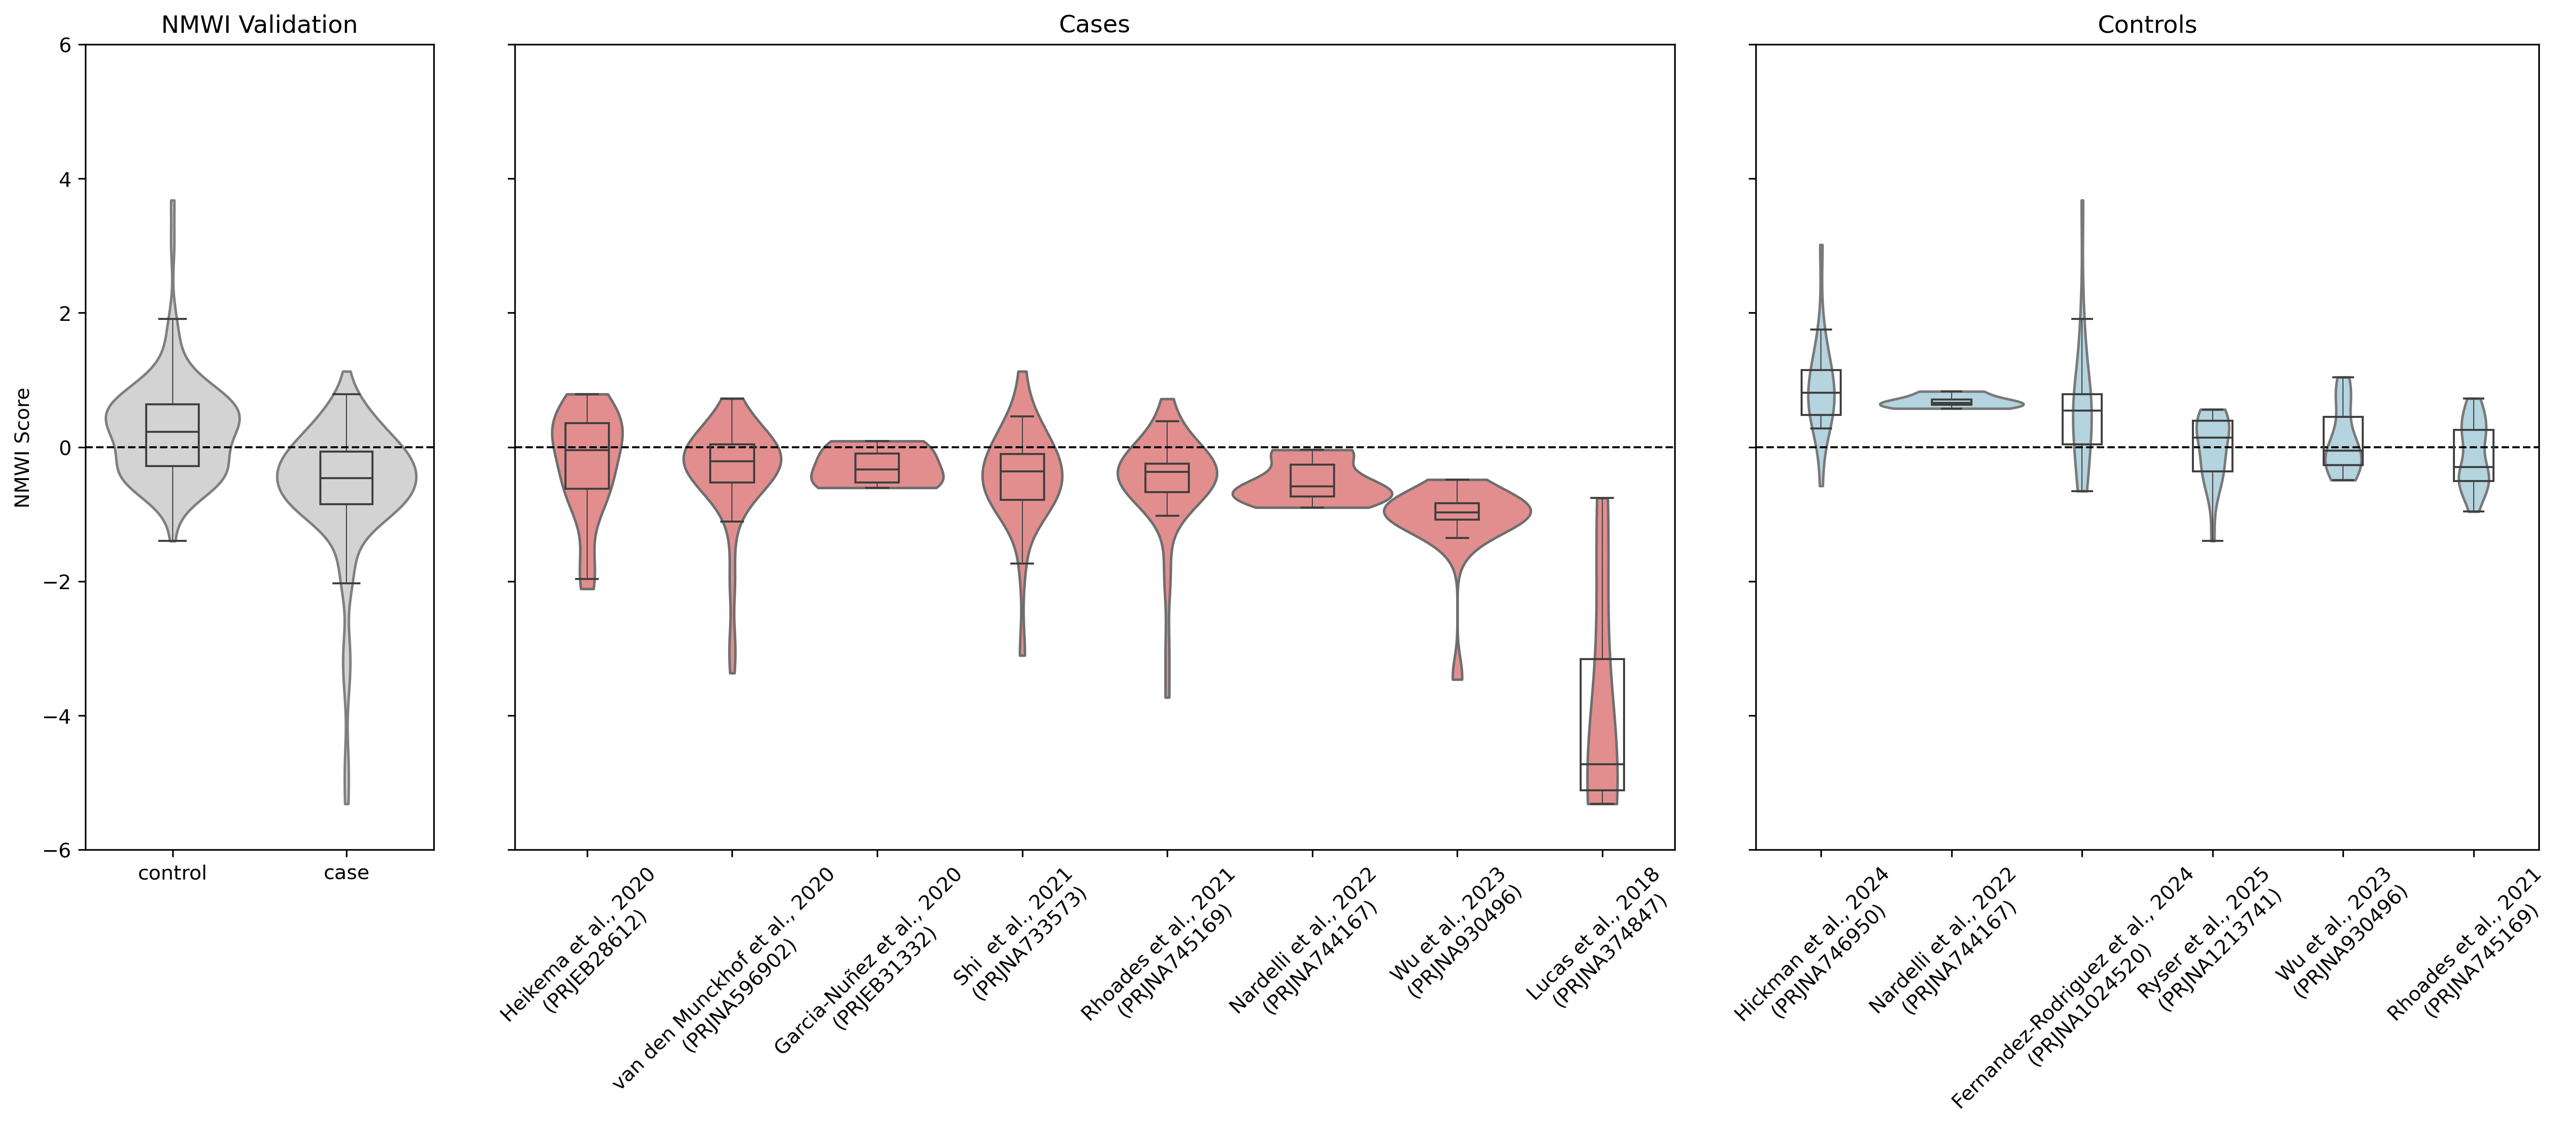

,Group_1,Group_2,N_1,N_2,Cliffs_delta,MannWhitney_p
0,case,control,241,109,-0.570825,1.202510e-17


In [16]:
meta_val = validation_meta.reset_index()[["Category", "Disease", "BioProject.Number", "Citation"]].copy()
meta_val["NMWI"] = NMWI_scores.to_numpy().ravel()

meta_val["Category"] = meta_val["Category"].astype(str)
meta_val["Disease"] = meta_val["Disease"].astype(str)
meta_val["BioProject.Number"] = meta_val["BioProject.Number"].astype(str)
meta_val["Citation"] = meta_val["Citation"].astype(str)

# safer label in case citations repeat across BioProjects
meta_val["Study_Label"] = meta_val["Citation"] + "\n(" + meta_val["BioProject.Number"] + ")"

cases = meta_val.query("Category == 'case'").copy()
controls = meta_val.query("Category == 'control'").copy()

ylim = 6

case_order_label = cases.groupby("BioProject.Number")["NMWI"].median().sort_values(ascending=False).index.map(
    cases.drop_duplicates("BioProject.Number").set_index("BioProject.Number")["Study_Label"]).tolist()

control_order_label = controls.groupby("BioProject.Number")["NMWI"].median().sort_values(ascending=False).index.map(
    controls.drop_duplicates("BioProject.Number").set_index("BioProject.Number")["Study_Label"]).tolist()


fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 8),
    dpi=300,
    sharey=True,
    gridspec_kw={"width_ratios": [1.2, 4, 2.7]}
)

# Panel 1: overall validation
sns.violinplot(
    data=meta_val,
    x="Category",
    y="NMWI",
    order=["control", "case"],
    color="lightgray",
    inner=None,
    ax=axes[0],
    cut = 0
)
sns.boxplot(
    data=meta_val,
    x="Category",
    y="NMWI",
    order=["control", "case"],
    width=0.3,
    showcaps=True,
    boxprops={"facecolor": "none", "zorder": 3},
    showfliers=False,
    whiskerprops={"linewidth": 0.5},
    ax=axes[0]
)
axes[0].set(title="NMWI Validation", xlabel="", ylabel="NMWI Score", ylim=(-ylim, ylim))
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)

# Panel 2: case studies
sns.violinplot(
    data=cases,
    x="Study_Label",
    y="NMWI",
    order=case_order_label,
    color="lightcoral",
    inner=None,
    width=1.1,
    ax=axes[1],
    cut = 0
)
sns.boxplot(
    data=cases,
    x="Study_Label",
    y="NMWI",
    order=case_order_label,
    width=0.3,
    showcaps=True,
    boxprops={"facecolor": "none", "zorder": 3},
    showfliers=False,
    whiskerprops={"linewidth": 0.5},
    ax=axes[1]
)
axes[1].set(title="Cases", xlabel="", ylabel="NMWI Score", ylim=(-ylim, ylim))
axes[1].tick_params(axis="x", rotation=45)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)

# Panel 3: control studies
sns.violinplot(
    data=controls,
    x="Study_Label",
    y="NMWI",
    order=control_order_label,
    color="lightblue",
    inner=None,
    width=1.1,
    ax=axes[2],
    cut = 0
)
sns.boxplot(
    data=controls,
    x="Study_Label",
    y="NMWI",
    order=control_order_label,
    width=0.3,
    showcaps=True,
    boxprops={"facecolor": "none", "zorder": 3},
    showfliers=False,
    whiskerprops={"linewidth": 0.5},
    ax=axes[2]
)
axes[2].set(title="Controls", xlabel="", ylabel="NMWI Score", ylim=(-ylim, ylim))
axes[2].tick_params(axis="x", rotation=45)
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)

plt.tight_layout()
plt.savefig('Figures/Fig5a.pdf')
plt.show()

from scipy.stats import mannwhitneyu
from cliffs_delta import cliffs_delta

# keep only what we need
sub = meta_val[["Category", "NMWI"]].dropna().copy()

case_vals = sub.loc[sub["Category"] == "case", "NMWI"]
control_vals = sub.loc[sub["Category"] == "control", "NMWI"]

u, pval = mannwhitneyu(cases['NMWI'], controls['NMWI'], alternative="two-sided")
cliffs_delta = (2 * u) / (len(case_vals) * len(control_vals)) - 1

results = pd.DataFrame([{
    "Group_1": "case",
    "Group_2": "control",
    "N_1": len(case_vals),
    "N_2": len(control_vals),
    "Cliffs_delta": cliffs_delta,
    "MannWhitney_p": pval
}])

# verified with: d, res = cliffs_delta(cases['NMWI'],controls['NMWI'])
results


In [21]:
from scipy.stats import mannwhitneyu
# pooled healthy samples
healthy_vals = (
    meta_val.loc[meta_val["Category"] == "control", "NMWI"]
    .dropna()
)

results = []

case_projects = (
    meta_val.loc[meta_val["Category"] == "case", "BioProject.Number"]
    .dropna()
    .astype(str)
    .unique()
)

for project in case_projects:
    case_vals = (
        meta_val.loc[
            (meta_val["Category"] == "case") &
            (meta_val["BioProject.Number"].astype(str) == project),
            "NMWI"
        ]
        .dropna()
    )

    if len(case_vals) == 0 or len(healthy_vals) == 0:
        continue

    u, pval = mannwhitneyu(case_vals, healthy_vals, alternative="two-sided")
    cliffs_delta = (2 * u) / (len(case_vals) * len(healthy_vals)) - 1

    results.append({
        "BioProject.Number": project,
        "N_case": len(case_vals),
        "N_healthy": len(healthy_vals),
        "Cliffs_delta": cliffs_delta,
        "MannWhitney_p": pval,
        "Case_median_NMWI": case_vals.median(),
        "Healthy_median_NMWI": healthy_vals.median()
    })

bioproject_vs_healthy = pd.DataFrame(results).sort_values("MannWhitney_p")
bioproject_vs_healthy


,BioProject.Number,N_case,N_healthy,Cliffs_delta,MannWhitney_p,Case_median_NMWI,Healthy_median_NMWI
6,PRJNA930496,41,109,-0.954800,2.368271e-19,-0.973636,0.230205
7,PRJNA374847,7,109,-0.992136,3.002519e-10,-4.726582,0.230205
4,PRJNA745169,45,109,-0.582467,1.400969e-08,-0.371394,0.230205
2,PRJNA596902,69,109,-0.431459,1.281614e-06,-0.211245,0.230205
3,PRJNA733573,27,109,-0.528372,2.245878e-05,-0.362020,0.230205
5,PRJNA744167,11,109,-0.713094,1.029904e-04,-0.586963,0.230205
0,PRJEB28612,37,109,-0.304736,5.737853e-03,-0.048773,0.230205
1,PRJEB31332,4,109,-0.527523,7.463634e-02,-0.330939,0.230205


In [22]:
# pooled case samples
case_vals_pooled = (
    meta_val.loc[meta_val["Category"] == "case", "NMWI"]
    .dropna()
)

results = []

healthy_projects = (
    meta_val.loc[meta_val["Category"] == "control", "BioProject.Number"]
    .dropna()
    .astype(str)
    .unique()
)

for project in healthy_projects:
    healthy_vals = (
        meta_val.loc[
            (meta_val["Category"] == "control") &
            (meta_val["BioProject.Number"].astype(str) == project),
            "NMWI"
        ]
        .dropna()
    )

    if len(healthy_vals) == 0 or len(case_vals_pooled) == 0:
        continue

    u, pval = mannwhitneyu(healthy_vals, case_vals_pooled, alternative="two-sided")
    cliffs_delta = (2 * u) / (len(healthy_vals) * len(case_vals_pooled)) - 1

    results.append({
        "BioProject.Number": project,
        "N_healthy": len(healthy_vals),
        "N_case": len(case_vals_pooled),
        "Cliffs_delta": cliffs_delta,
        "MannWhitney_p": pval,
        "Healthy_median_NMWI": healthy_vals.median(),
        "Case_median_NMWI": case_vals_pooled.median()
    })

healthy_bioproject_vs_cases = pd.DataFrame(results).sort_values("MannWhitney_p")
healthy_bioproject_vs_cases

,BioProject.Number,N_healthy,N_case,Cliffs_delta,MannWhitney_p,Healthy_median_NMWI,Case_median_NMWI
2,PRJNA746950,18,241,0.883356,4.157298e-10,0.810496,-0.466028
4,PRJNA1024520,19,241,0.694256,4.775750e-07,0.547122,-0.466028
1,PRJNA744167,4,241,0.954357,1.328546e-05,0.657893,-0.466028
3,PRJNA930496,18,241,0.528354,1.866679e-04,-0.055111,-0.466028
5,PRJNA1213741,22,241,0.459072,3.681900e-04,0.143185,-0.466028
0,PRJNA745169,28,241,0.346473,2.710303e-03,-0.300847,-0.466028


### Figure 5. Diversity index

Category
case       1.429646
control    1.586325
Name: Shannon, dtype: float64
Category
case       33.589212
control    42.972477
Name: Chao1, dtype: float64


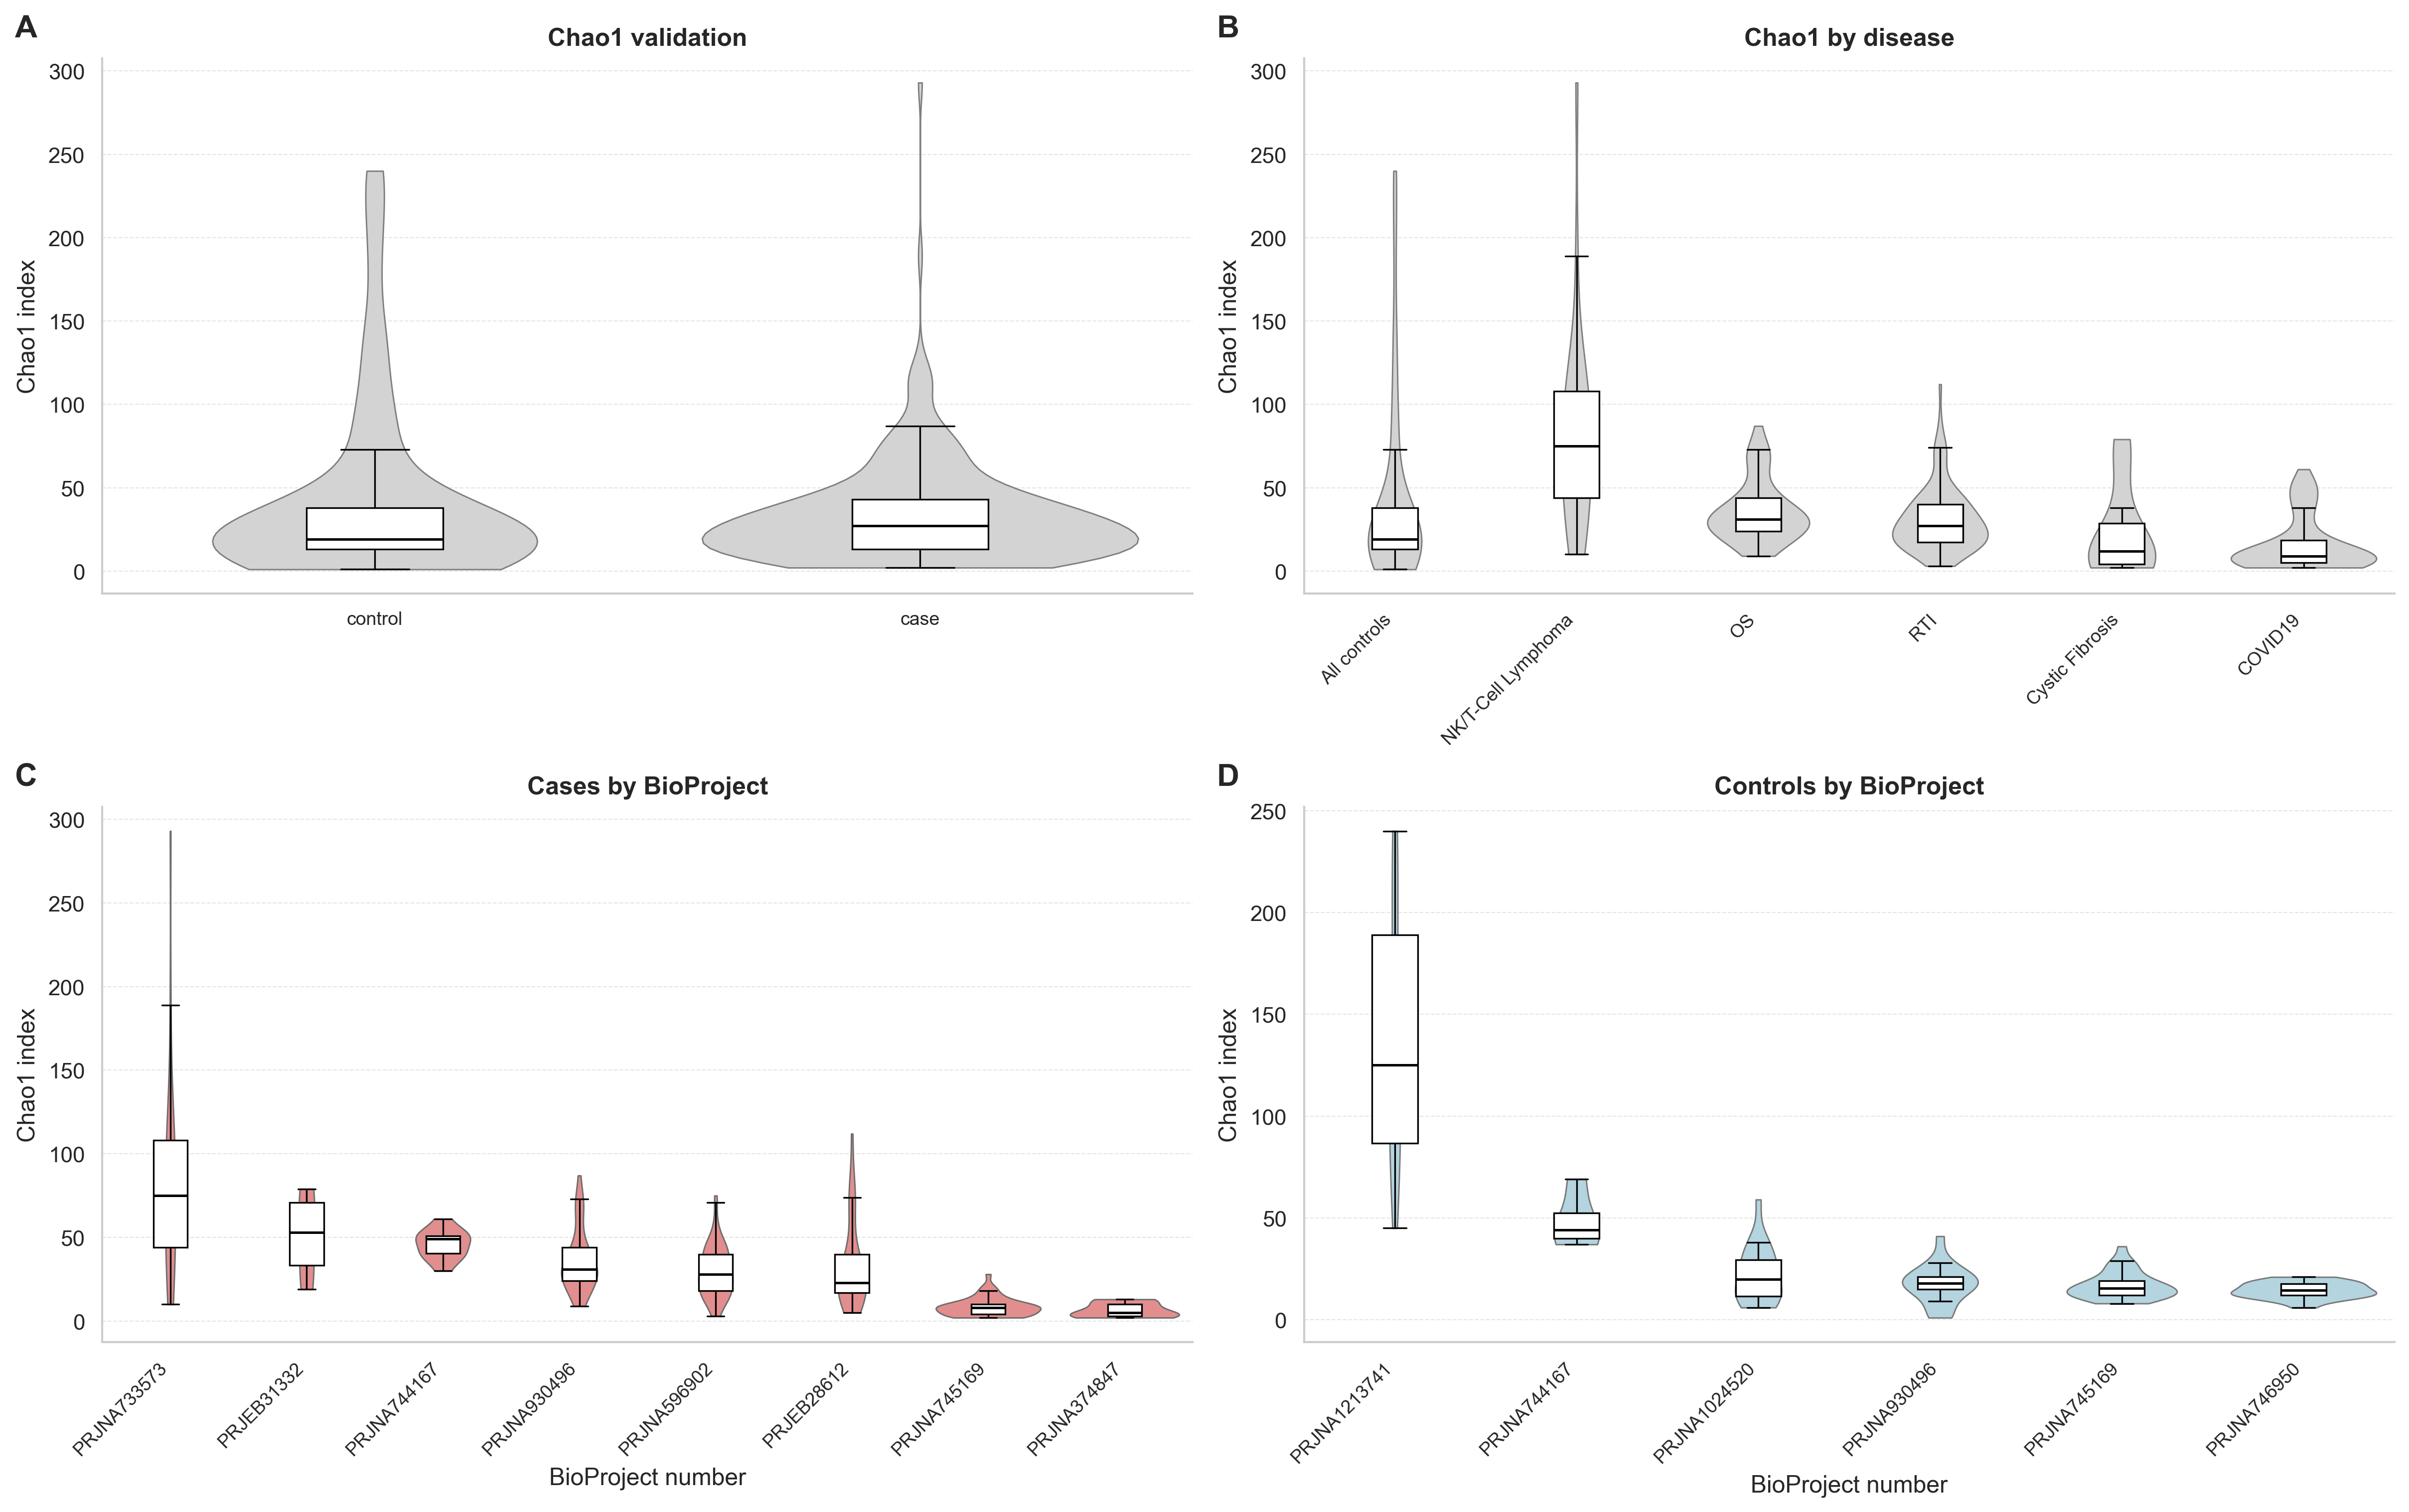

In [27]:
# Shannon index 
from scipy.stats import entropy

# prev = ((X_val>0).sum(axis=0)/X_val.shape[0]).T
# keep_taxa_val = prev[prev >= 0.05].index
# ra_sub_val = X_val.T.loc[keep_taxa_val]

filtered = pd.DataFrame({
    'Shannon': X_val.T.apply(lambda x: entropy(x[x > 0], base=np.e),axis=0),
    'Chao1': (X_val.T > 0).sum(axis=0)
        })

filtered.index.name = "Sample_id"
filtered = filtered.merge(sra_data_validation, on='Sample_id', how='left')
# filtered = filtered.set_index(['BioProject.Number', 'Sample_id'])

filtered["Category"] = filtered["Category"].astype(str)
filtered["Disease"] = filtered["Disease"].astype(str)
filtered["BioProject.Number"] = filtered["BioProject.Number"].astype(str)

print(filtered.groupby("Category")['Shannon'].mean())
print(filtered.groupby("Category")['Chao1'].mean())

meta_diversity = filtered.copy()

cases = meta_diversity.query("Category == 'case'")
controls = meta_diversity.query("Category == 'control'")

plot_df_disease = pd.DataFrame({
    "Group": pd.concat(
        [pd.Series(["All controls"] * len(controls)), cases["Disease"]],
        ignore_index=True
    ),
    "Shannon": pd.concat(
        [controls["Shannon"], cases["Shannon"]],
        ignore_index=True
    ),
        "Chao1": pd.concat(
        [controls["Chao1"], cases["Chao1"]],
        ignore_index=True
    )
})


import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    dpi=300,
    constrained_layout=True
)

axes = axes.flatten()

# Panel A: control vs case
sns.violinplot(
    data=meta_diversity,
    x="Category",
    y="Chao1",
    order=["control", "case"],
    inner=None,
    cut=0,
    linewidth=0.7,
    color="lightgray",
    ax=axes[0]
)

sns.boxplot(
    data=meta_diversity,
    x="Category",
    y="Chao1",
    order=["control", "case"],
    width=0.25,
    showfliers=False,
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 1.2},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    ax=axes[0]
)

axes[0].set_title("Chao1 validation", fontsize=12, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Chao1 index")


# Panel B: disease vs pooled controls
disease_order = (
    ["All controls"] +
    cases.groupby("Disease")["Chao1"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

sns.violinplot(
    data=plot_df_disease,
    x="Group",
    y="Chao1",
    order=disease_order,
    inner=None,
    cut=0,
    linewidth=0.7,
    color="lightgray",
    ax=axes[1]
)

sns.boxplot(
    data=plot_df_disease,
    x="Group",
    y="Chao1",
    order=disease_order,
    width=0.25,
    showfliers=False,
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 1.2},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    ax=axes[1]
)

axes[1].set_title("Chao1 by disease", fontsize=12, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Chao1 index")


# Panel C: cases by BioProject
case_project_order = (
    cases.groupby("BioProject.Number")["Chao1"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

sns.violinplot(
    data=cases,
    x="BioProject.Number",
    y="Chao1",
    order=case_project_order,
    inner=None,
    cut=0,
    linewidth=0.7,
    color="lightcoral",
    ax=axes[2]
)

sns.boxplot(
    data=cases,
    x="BioProject.Number",
    y="Chao1",
    order=case_project_order,
    width=0.25,
    showfliers=False,
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 1.2},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    ax=axes[2]
)

axes[2].set_title("Cases by BioProject", fontsize=12, fontweight="bold")
axes[2].set_xlabel("BioProject number")
axes[2].set_ylabel("Chao1 index")


# Panel D: controls by BioProject
control_project_order = (
    controls.groupby("BioProject.Number")["Chao1"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

sns.violinplot(
    data=controls,
    x="BioProject.Number",
    y="Chao1",
    order=control_project_order,
    inner=None,
    cut=0,
    linewidth=0.7,
    color="lightblue",
    ax=axes[3]
)

sns.boxplot(
    data=controls,
    x="BioProject.Number",
    y="Chao1",
    order=control_project_order,
    width=0.25,
    showfliers=False,
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 1.2},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    ax=axes[3]
)

axes[3].set_title("Controls by BioProject", fontsize=12, fontweight="bold")
axes[3].set_xlabel("BioProject number")
axes[3].set_ylabel("Chao1 index")


# General formatting
for ax, panel in zip(axes, ["A", "B", "C", "D"]):
    ax.text(
        -0.08,
        1.04,
        panel,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold"
    )

    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="x", rotation=45, labelsize=9)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

# Keep first panel labels horizontal
axes[0].tick_params(axis="x", rotation=0)
for label in axes[0].get_xticklabels():
    label.set_horizontalalignment("center")

plt.savefig(
    "Figures/Fig_Chao1_validation_4panel.pdf",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)

plt.show()

### Figure 5. Shannon

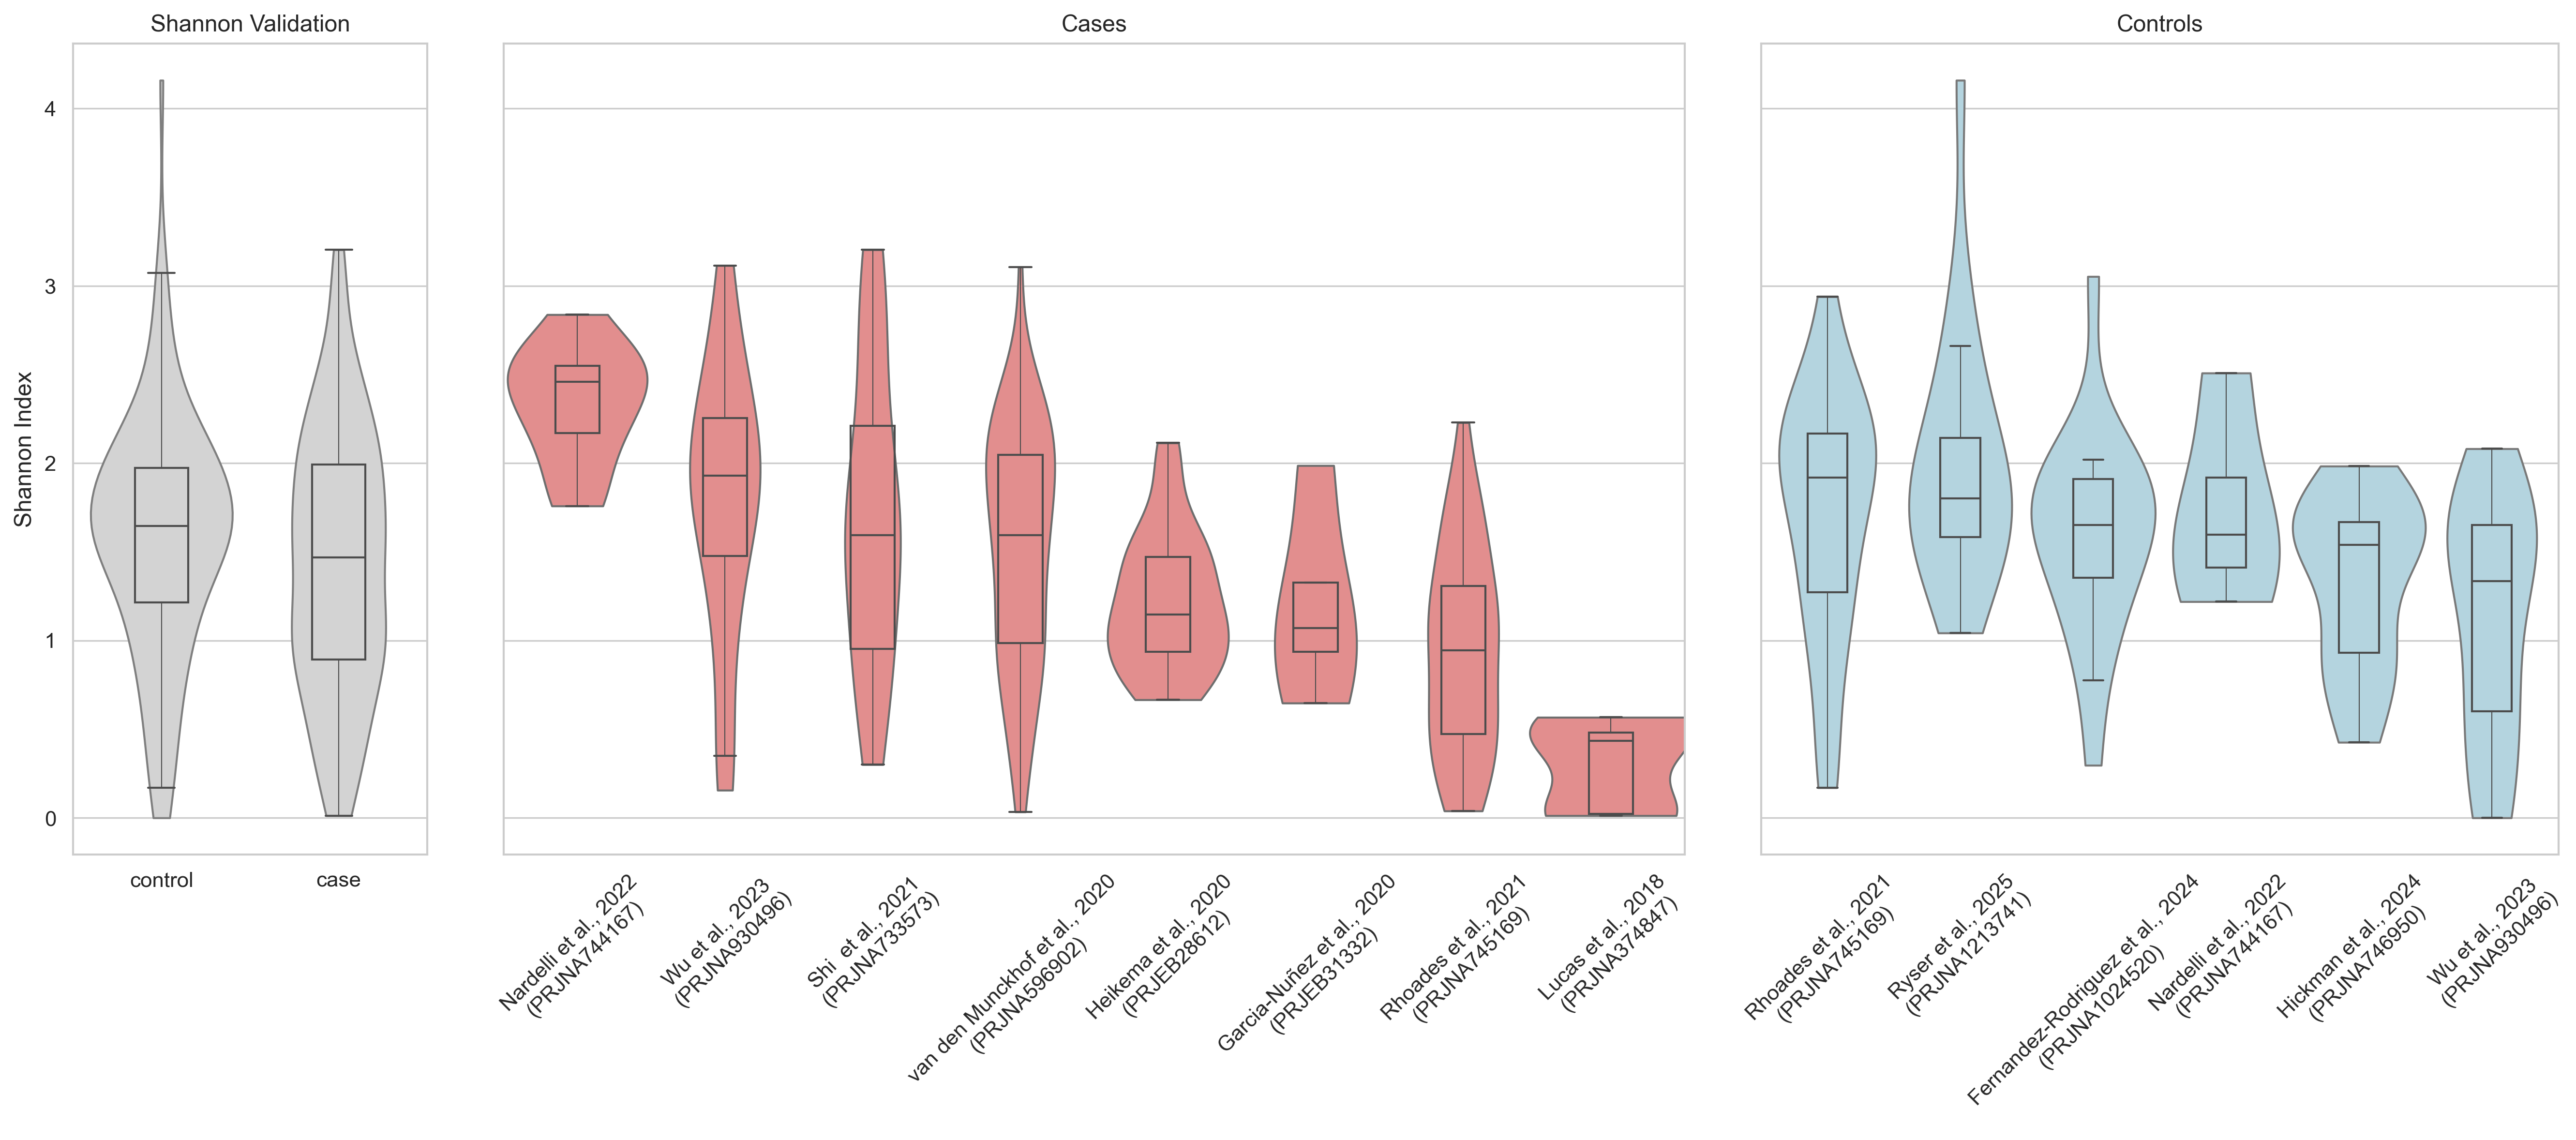

In [28]:
meta_diversity = filtered.merge(
    df_validation[["BioProject.Number", "Citation"]].drop_duplicates(),
    on="BioProject.Number",
    how="left"
)
# meta_diversity = meta_diversity[["Category", "Disease", "BioProject.Number", "Citation", "Shannon"]].copy()
meta_diversity["Category"] = meta_diversity["Category"].astype(str)
meta_diversity["Disease"] = meta_diversity["Disease"].astype(str)
meta_diversity["BioProject.Number"] = meta_diversity["BioProject.Number"].astype(str)
meta_diversity["Citation"] = meta_diversity["Citation"].astype(str)

meta_diversity["Study_Label"] = meta_diversity["Citation"] + "\n(" + meta_diversity["BioProject.Number"] + ")"

cases = meta_diversity.query("Category == 'case'").copy()
controls = meta_diversity.query("Category == 'control'").copy()

# ylim = 6

case_order_label = cases.groupby("BioProject.Number")["Shannon"].median().sort_values(ascending=False).index.map(
    cases.drop_duplicates("BioProject.Number").set_index("BioProject.Number")["Study_Label"]
).tolist()

control_order_label = controls.groupby("BioProject.Number")["Shannon"].median().sort_values(ascending=False).index.map(
    controls.drop_duplicates("BioProject.Number").set_index("BioProject.Number")["Study_Label"]
).tolist()

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 8),
    dpi=300,
    sharey=True,
    gridspec_kw={"width_ratios": [1.2, 4, 2.7]}
)

# Panel 1: overall validation
sns.violinplot(
    data=meta_diversity,
    x="Category",
    y="Shannon",
    order=["control", "case"],
    color="lightgray",
    inner=None,
    ax=axes[0],
    cut = 0
)
sns.boxplot(
    data=meta_diversity,
    x="Category",
    y="Shannon",
    order=["control", "case"],
    width=0.3,
    showcaps=True,
    boxprops={"facecolor": "none", "zorder": 3},
    showfliers=False,
    whiskerprops={"linewidth": 0.5},
    ax=axes[0],
    
)
axes[0].set(title="Shannon Validation", xlabel="", ylabel="Shannon Index",
            #  ylim=(0, ylim)
             )

# Panel 2: case studies
sns.violinplot(
    data=cases,
    x="Study_Label",
    y="Shannon",
    order=case_order_label,
    color="lightcoral",
    inner=None,
    width=1.1,
    ax=axes[1],
    cut = 0
)
sns.boxplot(
    data=cases,
    x="Study_Label",
    y="Shannon",
    order=case_order_label,
    width=0.3,
    showcaps=True,
    boxprops={"facecolor": "none", "zorder": 3},
    showfliers=False,
    whiskerprops={"linewidth": 0.5},
    ax=axes[1]
)
axes[1].set(title="Cases", xlabel="", ylabel="Shannon Index", 
            # ylim=(0, ylim)
            )
axes[1].tick_params(axis="x", rotation=45)

# Panel 3: control studies
sns.violinplot(
    data=controls,
    x="Study_Label",
    y="Shannon",
    order=control_order_label,
    color="lightblue",
    inner=None,
    width=1.,
    ax=axes[2],
    cut = 0
)
sns.boxplot(
    data=controls,
    x="Study_Label",
    y="Shannon",
    order=control_order_label,
    width=0.3,
    showcaps=True,
    boxprops={"facecolor": "none", "zorder": 3},
    showfliers=False,
    whiskerprops={"linewidth": 0.5},
    ax=axes[2]
)
axes[2].set(title="Controls", xlabel="", ylabel="Shannon Index", 
            # ylim=(0, ylim)
            )
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig('Figures/Fig5b.pdf')
plt.show()


In [29]:
from scipy.stats import mannwhitneyu
from cliffs_delta import cliffs_delta

# keep only what we need
sub_shannon = meta_diversity[["Category", "Shannon"]].dropna().copy()

shannon_case_vals = sub_shannon.loc[sub_shannon["Category"] == "case", "Shannon"]
shannon_control_vals = sub_shannon.loc[sub_shannon["Category"] == "control", "Shannon"]

u_shannon, pval_shannon = mannwhitneyu(shannon_case_vals, shannon_control_vals, alternative="two-sided")

cliffs_delta_shannon = (
    (2 * u_shannon) / (len(shannon_case_vals) * len(shannon_control_vals)) - 1
)

results_shannon = pd.DataFrame([{
    "Metric": "Shannon",
    "Group_1": "case",
    "Group_2": "control",
    "N_1": len(shannon_case_vals),
    "N_2": len(shannon_control_vals),
    "Cliffs_delta": cliffs_delta_shannon,
    "MannWhitney_p": pval_shannon
}])

# verified with:
# d_shannon, res_shannon = cliffs_delta(shannon_case_vals, shannon_control_vals)

results_shannon


,Metric,Group_1,Group_2,N_1,N_2,Cliffs_delta,MannWhitney_p
0,Shannon,case,control,241,109,-0.126347,0.058409


In [30]:
from scipy.stats import mannwhitneyu
from cliffs_delta import cliffs_delta

# keep only what we need
sub_Chao1 = meta_diversity[["Category", "Chao1"]].dropna().copy()

Chao1_case_vals = sub_Chao1.loc[sub_Chao1["Category"] == "case", "Chao1"]
Chao1_control_vals = sub_Chao1.loc[sub_Chao1["Category"] == "control", "Chao1"]

u_Chao1, pval_Chao1 = mannwhitneyu(Chao1_case_vals, Chao1_control_vals, alternative="two-sided")

cliffs_delta_Chao1 = (
    (2 * u_Chao1) / (len(Chao1_case_vals) * len(Chao1_control_vals)) - 1
)

results_Chao1 = pd.DataFrame([{
    "Metric": "Chao1",
    "Group_1": "case",
    "Group_2": "control",
    "N_1": len(Chao1_case_vals),
    "N_2": len(Chao1_control_vals),
    "Cliffs_delta": cliffs_delta_Chao1,
    "MannWhitney_p": pval_Chao1
}])

# verified with:
# d_Chao1, res_Chao1 = cliffs_delta(Chao1_case_vals, Chao1_control_vals)

results_Chao1


,Metric,Group_1,Group_2,N_1,N_2,Cliffs_delta,MannWhitney_p
0,Chao1,case,control,241,109,0.048765,0.465215


In [31]:
from scipy.stats import mannwhitneyu
import pandas as pd

# pooled healthy samples
healthy_vals = (filtered.loc[filtered["Category"] == "control", "Shannon"].dropna())
results = []

for project in case_projects:
    case_vals = (
        filtered.loc[
            (filtered["Category"] == "case") &
            (filtered["BioProject.Number"].astype(str) == project),
            "Shannon"
        ]
        .dropna()
    )

    if len(case_vals) == 0 or len(healthy_vals) == 0:
        continue

    u, pval = mannwhitneyu(case_vals, healthy_vals, alternative="two-sided")
    cliffs_delta = (2 * u) / (len(case_vals) * len(healthy_vals)) - 1

    results.append({
        "BioProject.Number": project,
        "N_case": len(case_vals),
        "N_healthy": len(healthy_vals),
        "Cliffs_delta": cliffs_delta,
        "MannWhitney_p": pval,
        "Case_median_NMWI": case_vals.median(),
        "Healthy_median_NMWI": healthy_vals.median()
    })

bioproject_vs_healthy = pd.DataFrame(results).sort_values("MannWhitney_p")
bioproject_vs_healthy


,BioProject.Number,N_case,N_healthy,Cliffs_delta,MannWhitney_p,Case_median_NMWI,Healthy_median_NMWI
4,PRJNA745169,45,109,-0.538022,1.603796e-07,0.944743,1.644969
7,PRJNA374847,7,109,-0.908257,1.108959e-06,0.433415,1.644969
5,PRJNA744167,11,109,0.733111,6.536020e-05,2.457813,1.644969
0,PRJEB28612,37,109,-0.412348,1.849854e-04,1.145839,1.644969
6,PRJNA930496,41,109,0.217275,4.083379e-02,1.930008,1.644969
1,PRJEB31332,4,109,-0.357798,2.386510e-01,1.070153,1.644969
3,PRJNA733573,27,109,0.032280,7.976351e-01,1.594727,1.644969
2,PRJNA596902,69,109,-0.015025,8.672193e-01,1.593613,1.644969


In [32]:
# pooled case samples
case_vals_pooled = (filtered.loc[filtered["Category"] == "case", "Shannon"].dropna())

results = []

healthy_projects = (filtered.loc[filtered["Category"] == "control", "BioProject.Number"].dropna().astype(str).unique())

for project in healthy_projects:
    healthy_vals = (
        filtered.loc[
            (filtered["Category"] == "control") &
            (filtered["BioProject.Number"].astype(str) == project),
            "Shannon"
        ]
        .dropna()
    )

    if len(healthy_vals) == 0 or len(case_vals_pooled) == 0:
        continue

    u, pval = mannwhitneyu(healthy_vals, case_vals_pooled, alternative="two-sided")
    cliffs_delta = (2 * u) / (len(healthy_vals) * len(case_vals_pooled)) - 1

    results.append({
        "BioProject.Number": project,
        "N_healthy": len(healthy_vals),
        "N_case": len(case_vals_pooled),
        "Cliffs_delta": cliffs_delta,
        "MannWhitney_p": pval,
        "Healthy_median_NMWI": healthy_vals.median(),
        "Case_median_NMWI": case_vals_pooled.median()
    })

healthy_bioproject_vs_cases = pd.DataFrame(results).sort_values("MannWhitney_p")
healthy_bioproject_vs_cases

,BioProject.Number,N_healthy,N_case,Cliffs_delta,MannWhitney_p,Healthy_median_NMWI,Case_median_NMWI
5,PRJNA1213741,22,241,0.392682,0.002315,1.801401,1.468625
0,PRJNA745169,28,241,0.241849,0.036360,1.918885,1.468625
3,PRJNA930496,18,241,-0.209313,0.139078,1.334776,1.468625
4,PRJNA1024520,19,241,0.126884,0.358132,1.649906,1.468625
1,PRJNA744167,4,241,0.253112,0.402005,1.597200,1.468625
2,PRJNA746950,18,241,-0.071923,0.612006,1.538985,1.468625
